# Analyse Exploratoire et Nettoyage – SénCrédit

**Objectif :** préparer les données pour la modélisation et comprendre les facteurs de risque de défaut de paiement, **sans introduire de fuite de données** (voir explication plus bas).

Ce notebook est écrit pour être compréhensible même si vous débutez en data science. Chaque étape technique est précédée d'une explication en langage simple. Un petit lexique récapitulatif se trouve à la toute fin.


**Plan :**
1. Chargement et aperçu des données
2. Lexique express pour débutants
3. Nettoyage déterministe (doublons, texte, valeurs impossibles)
4. Sauvegarde du dataset "propre mais pas encore imputé"
5. Analyse exploratoire (univariée, bivariée, corrélations)
6. Insights métier et recommandations
7. Lexique complet en fin de notebook


## 🧭 Avant de commencer : quelques mots-clés

- **DataFrame** : un tableau de données (comme un fichier Excel) manipulé avec la librairie `pandas`.
- **Ligne / observation** : ici, un commerçant.
- **Colonne / variable / feature** : une caractéristique du commerçant (zone, volume de ventes, etc.).
- **Cible (target)** : la colonne qu'on veut prédire, ici `Defaut_Paiement` (0 = bon payeur, 1 = mauvais payeur).
- **Valeur manquante (NaN)** : une case vide dans le tableau, faute de donnée disponible.
- **Valeur aberrante (outlier)** : une valeur suspecte ou impossible (ex : ancienneté négative).
- **EDA (Exploratory Data Analysis)** : l'étape où on regarde, résume et visualise les données *avant* de faire quoi que ce soit d'automatique, pour comprendre ce qu'on manipule.

D'autres termes seront expliqués au fur et à mesure. Un lexique complet est disponible à la fin du notebook.

**Pré-requis technique (à installer une seule fois, si besoin) :**
```
pip install pandas numpy matplotlib seaborn
```


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)  # pour que les resultats aleatoires soient reproductibles


**Ce que fait chaque librairie :**
- `pandas` : manipuler des tableaux de données (le cœur de ce notebook).
- `numpy` : calcul numérique (moyennes, valeurs manquantes `np.nan`, etc.).
- `matplotlib` / `seaborn` : créer des graphiques.
- `np.random.seed(42)` : fixe le "hasard" pour que, si on relance le notebook, on obtienne exactement les mêmes résultats aléatoires. Le nombre 42 n'a rien de magique, c'est juste une convention courante.


## 1. Chargement et aperçu des données

On charge le fichier brut (non nettoyé) et on regarde :
- ses dimensions (nombre de lignes = commerçants, nombre de colonnes = variables) ;
- les premières lignes, pour se faire une idée visuelle ;
- le nombre de valeurs manquantes par colonne.

**Pourquoi c'est important ?** Avant de nettoyer ou de modéliser quoi que ce soit, il faut savoir ce qu'on a entre les mains. C'est comme inspecter des ingrédients avant de cuisiner.


In [ ]:
df_raw = pd.read_csv('https://raw.githubusercontent.com/Dev0cb/ML_DAY/refs/heads/main/sencredit_dirty_dataset.csv')
print(f"Dimensions : {df_raw.shape}")
display(df_raw.head())
display(df_raw.isnull().sum())


**Comment lire ce résultat ?**
- `Dimensions : (10025, 8)` signifie 10 025 commerçants et 8 colonnes.
- Le tableau `.isnull().sum()` compte, colonne par colonne, le nombre de cases vides (`NaN`). Par exemple, si `Secteur_Activite` affiche 300, cela veut dire que 300 commerçants n'ont pas de secteur renseigné.

On garde ces chiffres en tête : ils vont nous permettre de vérifier, plus tard, que nos étapes de nettoyage se comportent comme prévu.


## 2. Nettoyage déterministe

On appelle "nettoyage déterministe" les corrections qui ne dépendent **pas** de calculs statistiques sur la cible ou sur l'ensemble du dataset (moyenne, médiane, mode...). Ce sont des règles fixes, sûres à appliquer sur toutes les données sans risque de "fuite" (voir l'encadré plus bas pour la fuite de données).

### 2.1 Doublons

Un **doublon** est une ligne strictement identique à une autre. Cela peut arriver, par exemple, si le même commerçant a été enregistré deux fois par erreur. On les supprime car ils fausseraient les statistiques (un même commerçant compterait pour deux).


In [ ]:
df = df_raw.copy()
n_avant = len(df)
df = df.drop_duplicates()
n_apres = len(df)
print(f"Lignes avant suppression des doublons : {n_avant}")
print(f"Lignes apres suppression des doublons : {n_apres}")
print(f"Nombre de doublons supprimes : {n_avant - n_apres}")


### 2.2 Normalisation du texte (zones)

Les données saisies à la main contiennent souvent des variantes d'écriture pour la même chose : espaces en trop, majuscules incohérentes, noms légèrement différents pour un même lieu (ex : "Marché Sandaga" vs "Sandaga").

On applique 3 étapes :
1. Nettoyer les espaces superflus.
2. Uniformiser la casse (première lettre en majuscule).
3. Remplacer les variantes connues par un nom unique.

⚠️ **Limite importante** : cette liste de remplacement n'est pas exhaustive. Elle corrige les variantes *connues à ce jour*. Pour cette raison, on affiche la liste des valeurs uniques **avant et après** normalisation : si vous repérez une nouvelle variante (ex : "sandaga marche", "PARCELLE ASSAINIE"), il faut l'ajouter au dictionnaire ci-dessous. Ce contrôle visuel manuel est volontaire : une normalisation 100% automatique (floue) risquerait de fusionner par erreur deux zones réellement différentes.


In [ ]:
print("Valeurs uniques AVANT normalisation :")
print(sorted(df['Zone_Dakar'].dropna().unique()))


In [ ]:
# Nettoyage des espaces multiples/superflus + casse uniforme
df['Zone_Dakar'] = (
    df['Zone_Dakar']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
)

# Dictionnaire des variantes connues -> nom canonique
# A COMPLETER si de nouvelles variantes apparaissent (voir cellule precedente)
mapping_zones = {
    'Marché Sandaga': 'Sandaga',
    'Marche Sandaga': 'Sandaga',
    'Parcelles Assainies': 'Parcelles',
}
df['Zone_Dakar'] = df['Zone_Dakar'].replace(mapping_zones)

print("Valeurs uniques APRES normalisation :")
print(sorted(df['Zone_Dakar'].dropna().unique()))


### 2.3 Valeurs impossibles ou suspectes → valeurs manquantes

Certaines valeurs sont **impossibles** ou **suspectes** :
- `Anciennete_Mois` négative : une ancienneté ne peut pas être négative. C'est certainement une erreur de saisie.
- `Volume_Mensuel_FCFA` égal à 0 : un volume de vente strictement nul est suspect pour un commerçant actif. **Hypothèse à valider avec le métier** — il est possible qu'un volume à 0 corresponde à un nouveau commerçant sans activité enregistrée pendant la période, auquel cas ce ne serait **pas** une erreur mais une vraie information ! Nous choisissons ici de traiter cela comme une valeur manquante par prudence, mais cette hypothèse **doit être confirmée par une personne connaissant le métier** avant un déploiement en production.

Dans les deux cas, on convertit la valeur suspecte en `NaN` (valeur manquante) plutôt que de la deviner nous-mêmes. La devinette (l'**imputation**) se fera plus tard, et uniquement à partir des données d'entraînement — voir l'encadré ci-dessous.

---

### 🚨 Pourquoi on n'impute PAS ici : la fuite de données ("data leakage")

Imaginez un·e élève qui révise un examen en s'entraînant... avec le corrigé de l'examen sous les yeux. Ses résultats à l'entraînement seront excellents, mais totalement trompeurs : le jour de l'examen réel (sans corrigé), ses résultats s'effondreront.

C'est exactement ce qui se passe si on calcule une statistique (comme "la médiane du volume de vente") sur **l'ensemble des données**, puis qu'on l'utilise pour remplacer les valeurs manquantes, **avant** d'avoir séparé les données en :
- un **ensemble d'entraînement** (train) : ce sur quoi le modèle apprend ;
- un **ensemble de test** (test) : ce qui simule les "nouveaux commerçants" jamais vus, pour évaluer honnêtement le modèle.

Si la médiane utilisée pour remplir les trous inclut déjà des informations du test, alors le modèle "a triché" un peu : le test n'est plus un vrai test à l'aveugle. On appelle cela une **fuite de données (data leakage)**.

**La solution :** dans ce notebook, on se contente de transformer les valeurs impossibles en `NaN`, sans les remplacer. On sauvegarde le fichier **avec ces `NaN` encore présents**. C'est dans le notebook de modélisation, **après** avoir séparé train/test, qu'on calculera les médianes **uniquement sur le train**, et qu'on les appliquera pour remplir les trous du train *et* du test.


In [ ]:
n_ancien_negatif = (df['Anciennete_Mois'] < 0).sum()
n_volume_nul = (df['Volume_Mensuel_FCFA'] == 0).sum()
print(f"Lignes avec anciennete negative (converties en NaN) : {n_ancien_negatif}")
print(f"Lignes avec volume a 0 (converties en NaN)          : {n_volume_nul}")

df.loc[df['Anciennete_Mois'] < 0, 'Anciennete_Mois'] = np.nan
df.loc[df['Volume_Mensuel_FCFA'] == 0, 'Volume_Mensuel_FCFA'] = np.nan


### 2.4 Bilan des valeurs manquantes après nettoyage déterministe

On regarde à nouveau les valeurs manquantes. Elles sont **plus nombreuses qu'au départ** (colonnes `Anciennete_Mois` et `Volume_Mensuel_FCFA` en plus), ce qui est normal et voulu : on vient de "démasquer" des valeurs qui étaient fausses en les rendant explicitement manquantes plutôt que de les laisser polluer silencieusement les statistiques.

**On ne comble aucune de ces valeurs manquantes ici.** C'est fait exprès (voir encadré ci-dessus). La colonne `Evolution_Ventes_3M_Pct`, qui avait déjà des valeurs manquantes dans le fichier brut, n'est pas non plus modifiée ici : on la laisse telle quelle, elle aussi sera traitée dans le notebook de modélisation.


In [ ]:
print("Valeurs manquantes par colonne (apres nettoyage deterministe) :")
display(df.isnull().sum())

pct_manquant = (df.isnull().sum() / len(df) * 100).round(2)
print("\nPourcentage de valeurs manquantes par colonne :")
display(pct_manquant)


### 2.5 Sauvegarde du fichier "propre mais pas imputé"

On sauvegarde ce fichier sous un nouveau nom pour bien marquer qu'il a été nettoyé (doublons supprimés, texte normalisé, valeurs impossibles transformées en `NaN`) mais **pas encore imputé**. C'est ce fichier que le notebook de modélisation chargera.


In [ ]:
df.to_csv('sencredit_clean.csv', index=False)
print("Fichier sauvegarde : sencredit_clean.csv")
print(f"Dimensions finales : {df.shape}")
print(f"Total de valeurs manquantes restantes : {df.isnull().sum().sum()}")


## 3. Analyse exploratoire (EDA)

Maintenant qu'on a un dataset propre (mais toujours avec quelques valeurs manquantes, volontairement), on peut l'explorer visuellement.

⚠️ **Note technique importante** : pour certains graphiques ci-dessous, on utilise une **copie temporaire** du dataset où les lignes avec valeurs manquantes sur les colonnes concernées sont simplement ignorées (`.dropna()`), uniquement pour que les graphiques s'affichent proprement. **Cette copie n'est jamais sauvegardée et ne sert pas à la modélisation** — elle sert uniquement à visualiser. Le fichier `sencredit_clean.csv` sauvegardé plus haut garde bien tous les `NaN`.


### 3.1 Distribution de la cible

On regarde combien de commerçants sont en défaut de paiement (`Defaut_Paiement = 1`) par rapport aux bons payeurs (`Defaut_Paiement = 0`).

**Pourquoi c'est important ?** Si une classe est beaucoup plus rare que l'autre (ce qu'on appelle un **déséquilibre de classes**), cela influence fortement le choix des métriques d'évaluation et la stratégie de modélisation plus tard (voir notebook 2).


In [ ]:
sns.countplot(data=df, x='Defaut_Paiement')
plt.title('Defaut de paiement (0 = bon payeur, 1 = mauvais payeur)')
plt.show()

taux_defaut = df['Defaut_Paiement'].mean() * 100
print(f"Taux de defaut global : {taux_defaut:.2f}%")


**Interprétation :** si le taux de défaut est autour de 20%, cela veut dire que les classes sont déséquilibrées (4 bons payeurs pour 1 mauvais payeur environ). On en tiendra compte lors de la modélisation, car un modèle "paresseux" qui prédirait toujours "bon payeur" aurait déjà ~80% de bonnes réponses (accuracy) sans être du tout utile ! C'est pourquoi l'accuracy seule n'est pas une bonne mesure de performance ici (plus de détails dans le notebook 2).


### 3.2 Analyse par secteur et par zone

On regarde si le taux de défaut varie selon le secteur d'activité et la zone géographique. `groupby(...).mean()` ignore automatiquement les lignes où `Secteur_Activite` ou `Zone_Dakar` est manquant (`NaN`), donc ces graphiques sont fiables sans manipulation supplémentaire.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.groupby('Secteur_Activite')['Defaut_Paiement'].mean().sort_values().plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Taux de defaut par secteur')
df.groupby('Zone_Dakar')['Defaut_Paiement'].mean().sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Taux de defaut par zone')
plt.tight_layout()
plt.show()


⚠️ **Attention à l'interprétation** : une zone ou un secteur avec très peu de commerçants peut afficher un taux de défaut extrême (0% ou 100%) simplement par manque de données, pas parce que ce groupe est vraiment plus risqué. On y reviendra dans le notebook 2 avec la notion de **lissage (smoothing)**.


### 3.3 Relation entre ancienneté, volume et défaut

Ici on utilise une copie temporaire sans valeurs manquantes sur ces deux colonnes (`Anciennete_Mois`, `Volume_Mensuel_FCFA`), uniquement pour l'affichage — rappel : cette copie n'est **pas** sauvegardée.


Lignes utilisees pour ce graphique (sur 10000 au total) : 9608


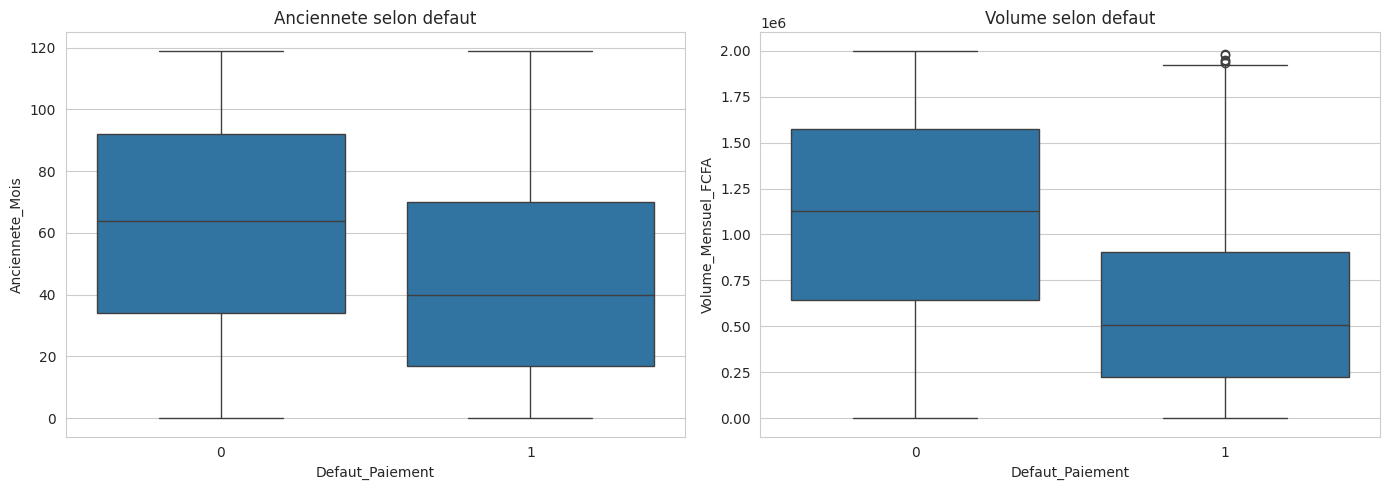

In [21]:
df_visu_num = df.dropna(subset=['Anciennete_Mois', 'Volume_Mensuel_FCFA'])
print(f"Lignes utilisees pour ce graphique (sur {len(df)} au total) : {len(df_visu_num)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_visu_num, x='Defaut_Paiement', y='Anciennete_Mois', ax=axes[0])
axes[0].set_title('Anciennete selon defaut')
sns.boxplot(data=df_visu_num, x='Defaut_Paiement', y='Volume_Mensuel_FCFA', ax=axes[1])
axes[1].set_title('Volume selon defaut')
plt.tight_layout()
plt.show()


### 3.4 Corrélations numériques

Une **corrélation** mesure à quel point deux variables évoluent ensemble (entre -1 et 1). Proche de 0 = pas de lien linéaire ; proche de 1 ou -1 = lien fort.

⚠️ **Sachez que** : Ici, on calcule la corrélation **uniquement sur les lignes où toutes les valeurs sont réellement connues** (`.dropna()`), ce qui donne une image plus honnête — même si elle repose sur moins de lignes.


Lignes utilisees pour la matrice de correlation (sur 10000 au total) : 9038


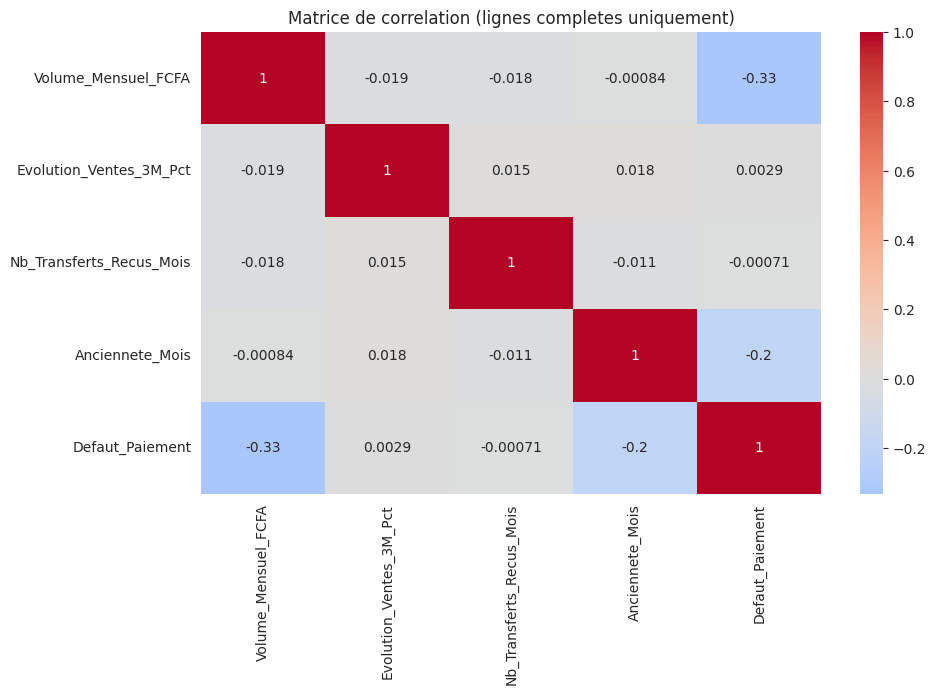

In [20]:
num_cols = ['Volume_Mensuel_FCFA', 'Evolution_Ventes_3M_Pct', 'Nb_Transferts_Recus_Mois', 'Anciennete_Mois']
df_visu_corr = df[num_cols + ['Defaut_Paiement']].dropna()
print(f"Lignes utilisees pour la matrice de correlation (sur {len(df)} au total) : {len(df_visu_corr)}")

corr = df_visu_corr.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de correlation (lignes completes uniquement)')
plt.show()


## 4. Insights métier (à confirmer avec la modélisation)

⚠️ Ces observations sont **descriptives** (elles décrivent ce qu'on voit dans les données) et ne prouvent pas de lien de cause à effet. Elles doivent être confirmées statistiquement lors de la modélisation (notebook 2), notamment via l'importance des variables dans le modèle final.

- **Taux de défaut global** : voir valeur calculée en §3.1 — c'est notre point de référence.
- Les commerçants avec une **faible ancienneté** et un **faible volume** semblent associés à un taux de défaut plus élevé (à confirmer par le modèle).
- Certains **secteurs** et **zones** ressortent avec des taux de défaut plus élevés dans ce dataset — mais attention, un secteur ou une zone avec peu de commerçants peut afficher un taux très instable simplement par manque de données (voir la notion de "lissage" expliquée dans le notebook 2).
- La colonne `Volume_Mensuel_FCFA == 0` a été traitée comme une erreur potentielle (voir §2.3) — **cette hypothèse doit être validée par le métier**, car elle pourrait au contraire être un signal prédictif légitime (nouveau commerçant sans activité).

Ces éléments guident la suite : le notebook 2 va imputer les valeurs manquantes correctement (sans fuite), construire des variables dérivées, et entraîner plusieurs modèles.


## 📖 Lexique complet (pour débutants)

| Terme | Définition simple |
|---|---|
| **DataFrame** | Tableau de données en `pandas`, comme une feuille Excel manipulable par le code. |
| **Ligne / observation** | Une entrée du tableau — ici, un commerçant. |
| **Colonne / variable / feature** | Une caractéristique mesurée — ici, zone, volume, etc. |
| **Cible (target)** | La variable qu'on veut prédire — ici, `Defaut_Paiement`. |
| **Valeur manquante (NaN)** | Une case vide, faute de donnée disponible. |
| **Valeur aberrante (outlier)** | Une valeur suspecte ou impossible (ex : ancienneté négative). |
| **Doublon** | Une ligne strictement identique à une autre, à supprimer. |
| **Imputation** | Le fait de remplacer une valeur manquante par une valeur estimée (moyenne, médiane...). |
| **Fuite de données (data leakage)** | Le fait d'utiliser, même involontairement, une information qu'on n'aurait pas dû avoir au moment de la prédiction, ce qui rend l'évaluation du modèle trop optimiste et trompeuse. |
| **Train / Test split** | Séparer les données en deux groupes : un pour entraîner le modèle, un pour l'évaluer honnêtement sur des données jamais vues. |
| **EDA (Exploratory Data Analysis)** | L'étape d'exploration visuelle et statistique des données avant modélisation. |
| **Corrélation** | Mesure (entre -1 et 1) du lien linéaire entre deux variables numériques. |
| **Déséquilibre de classes** | Quand une catégorie de la cible est beaucoup plus fréquente que l'autre (ex : 80% bons payeurs / 20% mauvais payeurs). |

➡️ Rendez-vous dans le notebook **2_Modelisation** pour la suite : imputation sans fuite, construction de variables, entraînement et évaluation de plusieurs modèles de machine learning.
